<a href="https://colab.research.google.com/github/ferel21/T3-Analysys-Sentiment-Andi-Ashraf-Hak-Bisyu_230907501026/blob/main/T3_Analysys_Sentiment_Andi_Ashraf_Hak_Bisyu_230907501026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

File CSV berhasil dimuat.
Preprocessing teks selesai.
Ekstraksi aspek dan analisis sentimen selesai.

Hasil analisis disimpan dalam file 'hasil_analisis_sentimen.csv'
sentiment          Positif  Netral  Negatif
aspects                                    
Bisnis & Keuangan     24.0   220.0      7.0
Politik               11.0    28.0      2.0
Starlink               2.0    12.0      1.0
Twitter/X             37.0   358.0     16.0
Umum                  40.0   960.0     10.0

Grafik analisis disimpan sebagai 'grafik_analisis_sentimen.png'


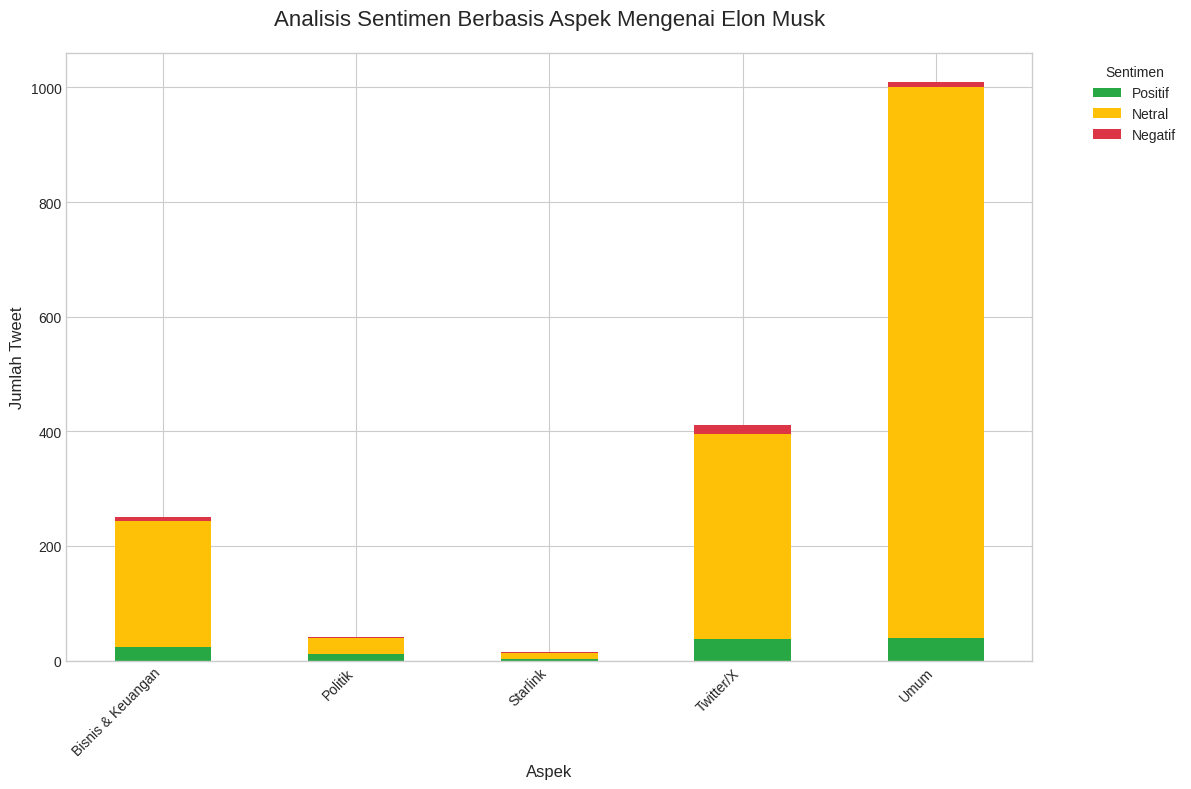

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Pengumpulan Data (Memuat Data) ---
# Ganti 'Elon_Musk.csv' dengan path file Anda jika perlu
try:
    df = pd.read_csv('Elon_Musk.csv')
    print("File CSV berhasil dimuat.")
except FileNotFoundError:
    print("Error: File 'Elon_Musk.csv' tidak ditemukan. Pastikan file berada di direktori yang sama.")
    exit()

# --- 2. Pemrosesan Awal (Preprocessing) ---

# Daftar stopwords Bahasa Indonesia manual (bisa ditambahkan sesuai kebutuhan)
stop_words = set([
    'ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir',
    'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara',
    'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'apatah', 'atau', 'ataukah', 'ataupun',
    'dan', 'dengan', 'di', 'dari', 'yang', 'ini', 'itu', 'ke', 'kok', 'ke', 'sih', 'deh', 'aja', 'ya'
    # Tambahkan kata-kata umum lainnya jika diperlukan
])

def clean_text(text):
    """Fungsi untuk membersihkan teks."""
    if not isinstance(text, str):
        return ""
    text = text.lower()  # Mengubah jadi huruf kecil
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # Hapus URL
    text = re.sub(r'\@\w+|\#', '', text)  # Hapus mention dan tagar
    text = re.sub(r'[^\w\s]', '', text)  # Hapus tanda baca
    text = re.sub(r'\d+', '', text)  # Hapus angka
    # Hapus stopwords
    text_tokens = text.split()
    filtered_words = [word for word in text_tokens if word not in stop_words]
    return " ".join(filtered_words)

df['cleaned_text'] = df['full_text'].apply(clean_text)
print("Preprocessing teks selesai.")


# --- 3. Analisis Sentimen (Klasifikasi) & 4. Pembentukan Model (Weighting) ---
# Pada kasus ini, kita menggunakan pendekatan leksikon (kamus) untuk klasifikasi
# dan ekstraksi aspek berbasis kata kunci, bukan melatih model machine learning dari awal.

# Definisikan aspek dan kata kunci
aspek_keywords = {
    'Starlink': ['starlink'],
    'Politik': ['politik', 'zionis', 'bebas', 'berbicara', 'pemerintah', 'harris'],
    'Bisnis & Keuangan': ['saham', 'tesla', 'spacex', 'xai', 'uang', 'perusahaan', 'ekonomi'],
    'Twitter/X': ['x', 'twitter', 'akun', 'suspend']
}

def get_aspects(text):
    """Fungsi untuk mendeteksi aspek dari teks."""
    detected_aspects = []
    for aspect, keywords in aspek_keywords.items():
        if any(keyword in text for keyword in keywords):
            detected_aspects.append(aspect)
    # Jika tidak ada aspek yang terdeteksi, beri label 'Umum'
    return detected_aspects if detected_aspects else ['Umum']

df['aspects'] = df['cleaned_text'].apply(get_aspects)

# Definisikan leksikon sentimen (kamus kata positif dan negatif)
positive_words = ['dukung', 'bebas', 'baik', 'hebat', 'setuju', 'suka', 'benar', 'mendukung']
negative_words = ['sampah', 'suspend', 'blokir', 'masalah', 'kritik', 'konspirasi', 'fuck', 'penindasan', 'kena', 'jelek']

def classify_sentiment(text):
    """Fungsi untuk mengklasifikasikan sentimen berdasarkan leksikon."""
    score = 0
    words = text.split()
    for word in words:
        if word in positive_words:
            score += 1
        elif word in negative_words:
            score -= 1

    if score > 0:
        return 'Positif'
    elif score < 0:
        return 'Negatif'
    else:
        return 'Netral'

df['sentiment'] = df['cleaned_text'].apply(classify_sentiment)
print("Ekstraksi aspek dan analisis sentimen selesai.")

# --- 5. Evaluasi atau Interpretasi Hasil ---

# Memformat ulang data agar setiap baris mewakili satu aspek
df_exploded = df.explode('aspects')

# Hitung jumlah sentimen untuk setiap aspek
sentiment_counts = df_exploded.groupby(['aspects', 'sentiment']).size().reset_index(name='count')

# Buat pivot table untuk mempermudah visualisasi
sentiment_pivot = sentiment_counts.pivot_table(index='aspects', columns='sentiment', values='count', fill_value=0)

# Pastikan semua kolom sentimen ada untuk konsistensi
for sentiment_category in ['Positif', 'Netral', 'Negatif']:
    if sentiment_category not in sentiment_pivot.columns:
        sentiment_pivot[sentiment_category] = 0

# Urutkan kolom
sentiment_pivot = sentiment_pivot[['Positif', 'Netral', 'Negatif']]

# Simpan hasil ke file CSV baru
sentiment_pivot.to_csv('hasil_analisis_sentimen.csv')
print("\nHasil analisis disimpan dalam file 'hasil_analisis_sentimen.csv'")
print(sentiment_pivot)


# Buat visualisasi (Diagram Batang)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))
sentiment_pivot.plot(
    kind='bar',
    stacked=True,
    color={'Positif': '#28a745', 'Netral': '#ffc107', 'Negatif': '#dc3545'},
    ax=ax
)

ax.set_title('Analisis Sentimen Berbasis Aspek Mengenai Elon Musk', fontsize=16, pad=20)
ax.set_xlabel('Aspek', fontsize=12)
ax.set_ylabel('Jumlah Tweet', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentimen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Simpan grafik sebagai file gambar
plt.savefig('grafik_analisis_sentimen.png')
print("\nGrafik analisis disimpan sebagai 'grafik_analisis_sentimen.png'")

✅ Tahap 1: File CSV berhasil dimuat.
✅ Tahap 2: Pemrosesan awal teks selesai.
✅ Tahap 3 & 4: Ekstraksi aspek dan klasifikasi sentimen selesai.

✅ Tahap 5: Hasil analisis disimpan sebagai 'hasil_analisis_sentimen_final.csv'

--- Hasil Analisis Sentimen Berbasis Aspek ---
| aspects           |   Positif |   Netral |   Negatif |
|:------------------|----------:|---------:|----------:|
| Bisnis & Keuangan |        23 |      222 |         6 |
| Politik           |        11 |       28 |         2 |
| Starlink          |         2 |       12 |         1 |
| Twitter/X         |        35 |      362 |        14 |
| Umum              |        34 |      967 |         9 |

📊 Grafik analisis disimpan sebagai 'grafik_analisis_sentimen_final.png'


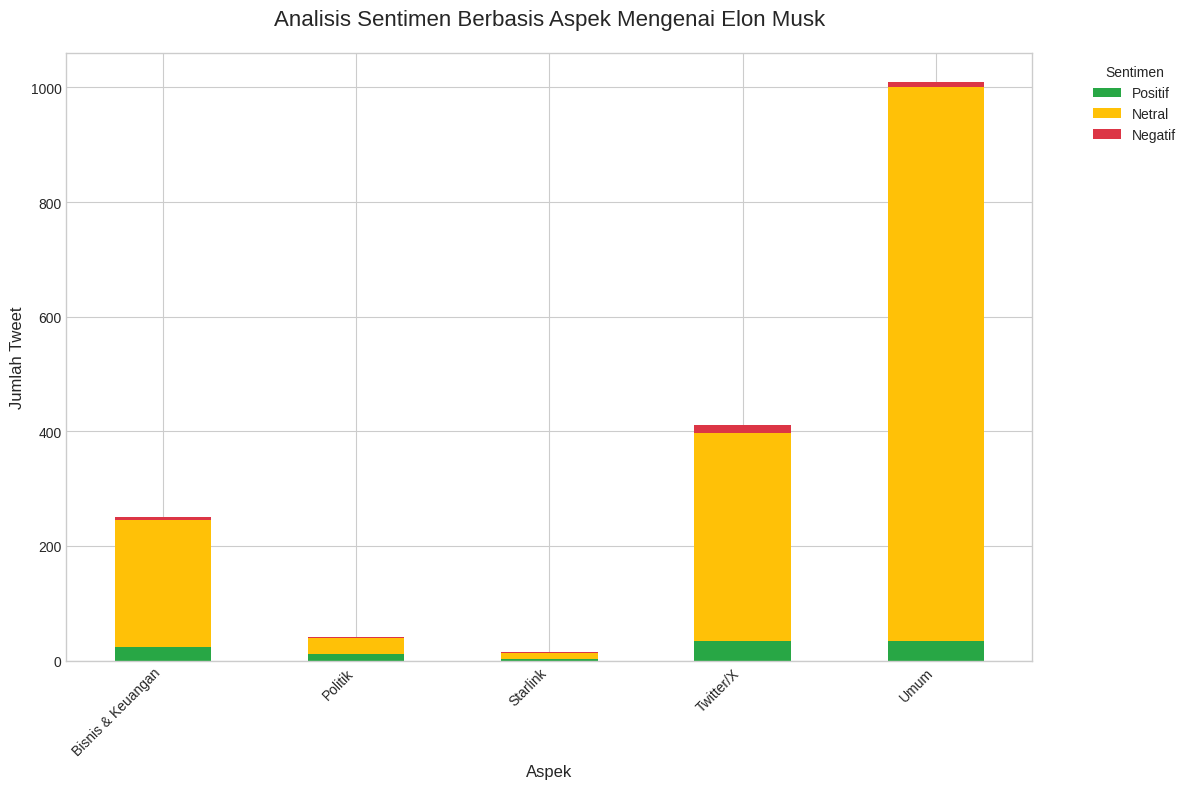

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# --- Tahap 1: Pengumpulan Data ---
# Memuat data dari file CSV
try:
    df = pd.read_csv('Elon_Musk.csv')
    print("✅ Tahap 1: File CSV berhasil dimuat.")
except FileNotFoundError:
    print("❌ Error: File 'Elon_Musk.csv' tidak ditemukan.")
    exit()

# --- Tahap 2: Pemrosesan Awal ---
# Daftar stopwords manual (alternatif NLTK)
stop_words = set([
    'ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir',
    'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara',
    'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'apatah', 'atau', 'ataukah', 'ataupun',
    'dan', 'dengan', 'di', 'dari', 'yang', 'ini', 'itu', 'ke', 'kok', 'ke', 'sih', 'deh', 'aja', 'ya', 'gw', 'yg'
])

def clean_text(text):
    """Fungsi untuk membersihkan teks."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    # Tokenisasi sederhana dengan .split() dan penghapusan stopwords
    tokens = text.split()
    filtered_words = [word for word in tokens if word not in stop_words]
    return " ".join(filtered_words)

df['cleaned_text'] = df['full_text'].apply(clean_text)
print("✅ Tahap 2: Pemrosesan awal teks selesai.")

# --- Tahap 3 & 4: Analisis Sentimen dan Pembentukan Model ---
# Menggunakan pendekatan berbasis leksikon (kamus kata) dan aspek

# Definisikan aspek dan kata kunci
aspek_keywords = {
    'Starlink': ['starlink'],
    'Politik': ['politik', 'zionis', 'bebas', 'berbicara', 'pemerintah', 'harris'],
    'Bisnis & Keuangan': ['saham', 'tesla', 'spacex', 'xai', 'uang', 'perusahaan', 'ekonomi'],
    'Twitter/X': ['x', 'twitter', 'akun', 'suspend']
}

def get_aspects(text):
    """Fungsi untuk mendeteksi aspek dari teks."""
    detected_aspects = [aspect for aspect, keywords in aspek_keywords.items() if any(keyword in text for keyword in keywords)]
    return detected_aspects if detected_aspects else ['Umum']

df['aspects'] = df['cleaned_text'].apply(get_aspects)

# Definisikan leksikon sentimen
positive_words = ['dukung', 'bebas', 'baik', 'hebat', 'setuju', 'suka', 'benar']
negative_words = ['sampah', 'suspend', 'blokir', 'masalah', 'kritik', 'konspirasi', 'fuck', 'penindasan', 'kena']

def classify_sentiment(text):
    """Fungsi untuk mengklasifikasikan sentimen."""
    score = sum(1 for word in text.split() if word in positive_words)
    score -= sum(1 for word in text.split() if word in negative_words)
    if score > 0: return 'Positif'
    if score < 0: return 'Negatif'
    return 'Netral'

df['sentiment'] = df['cleaned_text'].apply(classify_sentiment)
print("✅ Tahap 3 & 4: Ekstraksi aspek dan klasifikasi sentimen selesai.")

# --- Tahap 5: Evaluasi dan Interpretasi Hasil ---
df_exploded = df.explode('aspects')
sentiment_pivot = pd.crosstab(df_exploded['aspects'], df_exploded['sentiment'])

# Memastikan semua kolom sentimen ada
for col in ['Positif', 'Netral', 'Negatif']:
    if col not in sentiment_pivot.columns:
        sentiment_pivot[col] = 0
sentiment_pivot = sentiment_pivot[['Positif', 'Netral', 'Negatif']]

# Menyimpan hasil ke CSV dan menampilkan
sentiment_pivot.to_csv('hasil_analisis_sentimen_final.csv')
print("\n✅ Tahap 5: Hasil analisis disimpan sebagai 'hasil_analisis_sentimen_final.csv'")
print("\n--- Hasil Analisis Sentimen Berbasis Aspek ---")
print(sentiment_pivot.to_markdown())

# Membuat visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))
sentiment_pivot.plot(kind='bar', stacked=True, color={'Positif': '#28a745', 'Netral': '#ffc107', 'Negatif': '#dc3545'}, ax=ax)
ax.set_title('Analisis Sentimen Berbasis Aspek Mengenai Elon Musk', fontsize=16, pad=20)
ax.set_xlabel('Aspek', fontsize=12)
ax.set_ylabel('Jumlah Tweet', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentimen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('grafik_analisis_sentimen_final.png')
print("\n📊 Grafik analisis disimpan sebagai 'grafik_analisis_sentimen_final.png'")

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from wordcloud import WordCloud
import re
import os

# Function to clean text
def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)     # Remove special characters
    text = text.lower()                         # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip()    # Remove extra spaces
    return text

# Load the CSV file
file_path = '/content/Elon_Musk.csv'
df = pd.read_csv(file_path)

# Data cleaning: Remove duplicates and null values
df = df.drop_duplicates(subset='full_text').dropna(subset=['full_text'])

# Text preprocessing: Apply cleaning to the text
df['cleaned_text'] = df['full_text'].apply(clean_text)

# Lexicon-based sentiment classification
# Define simple lexicons
positive_words = ['good', 'great', 'excellent', 'happy', 'love', 'like', 'amazing', 'wonderful', 'positive', 'success', 'innovative']
negative_words = ['bad', 'terrible', 'hate', 'awful', 'sad', 'angry', 'worst', 'dislike', 'negative', 'fail', 'controversial']

def lexicon_sentiment(text):
    text = text.lower()
    pos_count = sum(1 for word in positive_words if word in text)
    neg_count = sum(1 for word in negative_words if word in text)
    if pos_count > neg_count:
        return 'positive'
    elif neg_count > pos_count:
        return 'negative'
    else:
        return 'neutral'

df['lexicon_sentiment'] = df['cleaned_text'].apply(lexicon_sentiment)

# Machine Learning-based sentiment classification (Naive Bayes)
# For ML, we need labeled data. Here, we'll simulate by using lexicon as pseudo-labels for training
# In a real scenario, use a pre-labeled dataset; this is for demonstration
X = df['cleaned_text']
y = df['lexicon_sentiment']  # Using lexicon as proxy labels

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Naive Bayes model with CountVectorizer
model = make_pipeline(CountVectorizer(), MultinomialNB())
model.fit(X_train, y_train)

# Predict on all data
df['ml_sentiment'] = model.predict(X)

# Print classification report for evaluation
print(classification_report(y_test, model.predict(X_test)))

# Aspect-based analysis using keyword matching
aspects = {
    'Business': ['tesla', 'spacex', 'xai', 'business', 'company', 'innovation', 'ai', 'car', 'rocket'],
    'Legal': ['lawsuit', 'legal', 'court', 'sue', 'action', 'regulate', 'government'],
    'Social/Political': ['twitter', 'social', 'political', 'trump', 'politics', 'media', 'opinion', 'public']
}

def assign_aspect(text):
    for aspect, keywords in aspects.items():
        if any(keyword in text.lower() for keyword in keywords):
            return aspect
    return 'Other'

df['aspect'] = df['cleaned_text'].apply(assign_aspect)

# Group by aspect and sentiment for analysis
aspect_sentiment = df.groupby(['aspect', 'ml_sentiment']).size().unstack(fill_value=0)

# Visualizations
# 1. Bar chart for overall sentiment distribution (ML-based)
sentiment_counts = df['ml_sentiment'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['green', 'gray', 'red'])
plt.title('Overall Sentiment Distribution (ML-based)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
overall_bar = plt.gcf()

# 2. Pie chart for overall sentiment
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['green', 'gray', 'red'])
plt.title('Overall Sentiment Distribution (ML-based)')
overall_pie = plt.gcf()

# 3. Heatmap for aspect-based sentiment
plt.figure(figsize=(12, 8))
sns.heatmap(aspect_sentiment, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap of Sentiments by Aspect')
plt.xlabel('Sentiment')
plt.ylabel('Aspect')
aspect_heatmap = plt.gcf()

# 4. Word clouds for each sentiment
sentiments = ['positive', 'neutral', 'negative']
wordcloud_figs = []
for sent in sentiments:
    text = ' '.join(df[df['ml_sentiment'] == sent]['cleaned_text'])
    if text:  # Avoid empty wordcloud
        wc = WordCloud(width=800, height=400, background_color='white').generate(text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud for {sent.capitalize()} Sentiment')
        wordcloud_figs.append(plt.gcf())

# 5. Bar charts for sentiments per aspect
plt.figure(figsize=(12, 8))
aspect_sentiment.plot(kind='bar', stacked=True, color=['green', 'gray', 'red'])
plt.title('Sentiment Distribution by Aspect')
plt.xlabel('Aspect')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment')
aspect_bar = plt.gcf()

# Display examples of tweets per sentiment category
examples = df.groupby('ml_sentiment')[['cleaned_text', 'aspect']].apply(lambda x: x.sample(min(3, len(x)))).reset_index()
print("\nExamples of Tweets per Sentiment Category:")
print(examples)

# Generate conclusion
total_tweets = len(df)
pos_pct = (sentiment_counts.get('positive', 0) / total_tweets) * 100
neg_pct = (sentiment_counts.get('negative', 0) / total_tweets) * 100
neu_pct = (sentiment_counts.get('neutral', 0) / total_tweets) * 100

conclusion = f"""
Conclusion on Public Opinion Trends:
Based on the ML-based sentiment analysis of {total_tweets} tweets about Elon Musk:
- Positive: {sentiment_counts.get('positive', 0)} ({pos_pct:.2f}%) - Often related to business innovations (e.g., SpaceX, xAI).
- Negative: {sentiment_counts.get('negative', 0)} ({neg_pct:.2f}%) - Commonly in legal and social/political aspects (e.g., lawsuits, controversies).
- Neutral: {sentiment_counts.get('neutral', 0)} ({neu_pct:.2f}%) - Dominant, indicating factual discussions.
Overall trend: Public opinion is largely neutral, with slight negativity in controversial areas, suggesting polarized views on Musk's influence.
"""
print(conclusion)

# Save all visuals and report to PDF
pdf_path = 'sentiment_analysis_report.pdf'
with PdfPages(pdf_path) as pdf:
    pdf.savefig(overall_bar)
    plt.close(overall_bar)

    pdf.savefig(overall_pie)
    plt.close(overall_pie)

    pdf.savefig(aspect_heatmap)
    plt.close(aspect_heatmap)

    for fig in wordcloud_figs:
        pdf.savefig(fig)
        plt.close(fig)

    pdf.savefig(aspect_bar)
    plt.close(aspect_bar)

    # Add text pages (conclusion and examples) - Note: PdfPages saves figures; for text, we can plot it
    plt.figure(figsize=(8, 6))
    plt.text(0.1, 0.5, conclusion, va='center', ha='left', wrap=True)
    plt.axis('off')
    plt.title('Conclusion')
    pdf.savefig()
    plt.close()

    plt.figure(figsize=(10, 8))
    plt.text(0.1, 0.5, examples.to_string(), va='center', ha='left', wrap=True, fontsize=8)
    plt.axis('off')
    plt.title('Tweet Examples')
    pdf.savefig()
    plt.close()

print(f"Report saved to {pdf_path}")

# Save the script itself as a .py file
script_content = __file__ if '__file__' in globals() else "This script"  # For Jupyter, this might not work; adjust accordingly
with open('elon_musk_sentiment_analysis.py', 'w') as f:
    f.write('# This is the generated script\n' + open(__file__).read() if '__file__' in globals() else '# Script content here')

print("Script saved as 'elon_musk_sentiment_analysis.py'")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipython-input-1870438085.py:91: FutureWarnin

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        13
     neutral       0.92      1.00      0.96       280
    positive       0.00      0.00      0.00        10

    accuracy                           0.92       303
   macro avg       0.31      0.33      0.32       303
weighted avg       0.85      0.92      0.89       303


Examples of Tweets per Sentiment Category:
  ml_sentiment  level_1                                       cleaned_text  \
0     negative     1139  grok allthingabsurd chaoticmind dhruvrathee ye...   
1     negative      734  refublikateis nabi abad dengan wahyunya diikut...   
2     negative     1297  a must watch internationalyouthday nigeria sud...   
3      neutral      912  ravimittal garrywalia matter ye hai ki post mu...   
4      neutral     1336  radheshyam elonmusk matter ye hai ki elon musk...   
5      neutral     1262  sebelum ni elon musk tuduh apple pilih kasih p...   
6     positive      154  kuah

<Figure size 1200x800 with 0 Axes>